# RF Optimisation: Balancing ParkCeleb Accuracy & KCL Generalisation

### The Problem
- SVM/GB: 90% on ParkCeleb but 42-58% on KCL → overfitting
- RF: 70% on ParkCeleb and 69% on KCL → consistent but lower

### Why SVM/GB overfit
The subject-level aggregation creates **mean + std** features.  
ParkCeleb subjects have many recordings → std features are informative.  
KCL subjects have ONE recording → std features are always 0.  
SVM/GB likely learned to rely on std features, which become meaningless on KCL.

### Strategy
1. Try RF with **mean-only** features (should transfer better to KCL)
2. Try RF with **mean+std** but constrained to not over-rely on std
3. Evaluate every config on **both** ParkCeleb test AND KCL
4. Rank by combined score (harmonic mean of both accuracies)

---

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PATHS — adjust to match your file locations            ║
# ╚══════════════════════════════════════════════════════════╝

# ParkCeleb
CYMO_PC    = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC    = './cymo_parkceleb_per_recording_metadata.csv'

# KCL (CYMO results from gold-standard transcription)
CYMO_KCL_RT = '../KCL/ann.cymo_kcl_readtext_full.csv'
META_KCL_RT = './cymo_kcl_readtext_full_metadata.csv'
CYMO_KCL_SD = '../KCL/ann.cymo_kcl_dialogue_full.csv'       # Dialogue
META_KCL_SD = './cymo_kcl_dialogue_full_metadata.csv'

# Features
FEAT_CSV   = './mrmr_top10_features.csv'

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

In [3]:
# ============================================================
# Load base features list
# ============================================================
base_features = pd.read_csv(FEAT_CSV)['feature'].tolist()
print(f'Base mRMR features: {len(base_features)}')
for f in base_features:
    print(f'  {f}')

Base mRMR features: 24
  N2SLOb
  wid
  TOPspo
  T50KCOCAw
  DETposs1p
  TOPhea
  PRNposs2
  TOPpol
  NSLOb
  QUANTon
  DETposs1s
  EMOmel
  NSNOb
  vVAR1
  DPCOCAanorm
  EMOann
  N2SFWOb
  CONJscond
  QUANTmn
  TOPent
  NSAOb
  PRNref2p
  TOPtec
  EMOfea


In [4]:
# ============================================================
# Load ParkCeleb → subject-level aggregation
# ============================================================
def load_cymo(cymo_path, meta_path, base_feats):
    cymo = pd.read_csv(cymo_path)
    meta = pd.read_csv(meta_path)
    tid = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
    mtid = 'TID' if 'TID' in meta.columns else meta.columns[0]
    
    # Find group and subject columns
    group_col = 'group' if 'group' in meta.columns else None
    subj_col = next((c for c in meta.columns if c in ('subject', 'subject_id')), None)
    
    merge_cols = [mtid]
    if group_col: merge_cols.append(group_col)
    if subj_col: merge_cols.append(subj_col)
    
    df = cymo.merge(meta[merge_cols].drop_duplicates(), left_on=tid, right_on=mtid, how='inner')
    
    if group_col:
        df['label'] = df[group_col].apply(lambda x: 1 if x == 'PD' else 0)
    
    if subj_col and subj_col != 'subject':
        df = df.rename(columns={subj_col: 'subject'})
    
    for col in base_feats:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            df[col] = 0.0
    df[base_feats] = df[base_feats].fillna(df[base_feats].median())
    
    return df


def aggregate_subjects(df, base_feats, mode='mean_only'):
    """Aggregate recordings to subject level.
    mode: 'mean_only' or 'mean_std'
    """
    if mode == 'mean_only':
        agg = {f: 'mean' for f in base_feats}
    else:
        agg = {f: ['mean', 'std'] for f in base_feats}
    agg['label'] = 'first'
    
    subj = df.groupby('subject').agg(agg).reset_index()
    
    if mode == 'mean_only':
        feat_cols = base_feats
    else:
        subj.columns = ['subject'] + [f'{a}_{b}' if isinstance(b, str) and b else str(a)
                                       for a, b in subj.columns[1:]]
        label_col = [c for c in subj.columns if 'label' in c][0]
        subj = subj.rename(columns={label_col: 'label'})
        feat_cols = [c for c in subj.columns if c not in ('subject', 'label')]
    
    subj = subj.fillna(0)
    return subj, feat_cols


# Load ParkCeleb
pc_df = load_cymo(CYMO_PC, META_PC, base_features)
print(f'ParkCeleb: {len(pc_df)} recordings, {pc_df["subject"].nunique()} subjects')

ParkCeleb: 143818 recordings, 100 subjects


In [5]:
# ============================================================
# Load KCL (for cross-corpus evaluation)
# ============================================================
kcl_dfs = []
for cymo_path, meta_path, task in [(CYMO_KCL_RT, META_KCL_RT, 'RT'),
                                     (CYMO_KCL_SD, META_KCL_SD, 'SD')]:
    try:
        kdf = load_cymo(cymo_path, meta_path, base_features)
        kdf['task'] = task
        kcl_dfs.append(kdf)
        print(f'KCL {task}: {len(kdf)} recordings, {kdf["subject"].nunique()} subjects')
    except FileNotFoundError:
        print(f'KCL {task}: file not found, skipping')

if kcl_dfs:
    kcl_all = pd.concat(kcl_dfs, ignore_index=True)
    print(f'KCL total: {len(kcl_all)} recordings, {kcl_all["subject"].nunique()} subjects')
else:
    kcl_all = None
    print('WARNING: No KCL data loaded. Cross-corpus eval will be skipped.')

KCL RT: 183 recordings, 37 subjects
KCL SD: 573 recordings, 36 subjects
KCL total: 756 recordings, 38 subjects


In [6]:
# ============================================================
# Evaluation function: ParkCeleb test + KCL cross-corpus
# ============================================================

def evaluate_rf_config(pc_df, kcl_all, base_feats, rf_params, agg_mode, seed):
    """
    Train RF on ParkCeleb train subjects, evaluate on:
      1. ParkCeleb test subjects
      2. KCL cross-corpus (if available)
    Returns dict of metrics.
    """
    # Aggregate ParkCeleb to subject level
    pc_subj, feat_cols = aggregate_subjects(pc_df, base_feats, mode=agg_mode)
    
    # 70/30 split
    np.random.seed(seed)
    cn = pc_subj[pc_subj['label'] == 0].sample(frac=1, random_state=seed)
    pd_g = pc_subj[pc_subj['label'] == 1].sample(frac=1, random_state=seed)
    cs, ps = int(len(cn) * 0.7), int(len(pd_g) * 0.7)
    train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
    test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])
    
    # Scale
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[feat_cols].values)
    X_te = scaler.transform(test[feat_cols].values)
    y_tr = train['label'].values
    y_te = test['label'].values
    
    # Train
    rf = RandomForestClassifier(**rf_params, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    
    # ParkCeleb test
    y_pred = rf.predict(X_te)
    y_prob = rf.predict_proba(X_te)[:, 1]
    pc_acc = accuracy_score(y_te, y_pred)
    pc_auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5
    
    result = {'pc_acc': pc_acc, 'pc_auc': pc_auc}
    
    # KCL cross-corpus
    if kcl_all is not None:
        if agg_mode == 'mean_only':
            # KCL: one recording per subject, just use features directly
            kcl_subj = kcl_all.groupby('subject').agg(
                {**{f: 'mean' for f in base_feats}, 'label': 'first'}
            ).reset_index()
            kcl_feat_cols = base_feats
        else:
            # KCL: aggregate (std will be 0 for single-recording subjects)
            kcl_subj, kcl_feat_cols = aggregate_subjects(kcl_all, base_feats, mode=agg_mode)
        
        # Ensure same feature columns
        for col in feat_cols:
            if col not in kcl_subj.columns:
                kcl_subj[col] = 0.0
        
        X_kcl = scaler.transform(kcl_subj[feat_cols].fillna(0).values)
        y_kcl = kcl_subj['label'].values
        
        kcl_pred = rf.predict(X_kcl)
        kcl_prob = rf.predict_proba(X_kcl)[:, 1]
        kcl_acc = accuracy_score(y_kcl, kcl_pred)
        kcl_auc = roc_auc_score(y_kcl, kcl_prob) if len(np.unique(y_kcl)) > 1 else 0.5
        
        result['kcl_acc'] = kcl_acc
        result['kcl_auc'] = kcl_auc
        # Combined score: harmonic mean of both accuracies
        result['combined'] = 2 * pc_acc * kcl_acc / (pc_acc + kcl_acc) if (pc_acc + kcl_acc) > 0 else 0
    
    return result

In [7]:
# ============================================================
# Run experiments
# ============================================================
N_SPLITS = 10  # 10 splits × many configs, still fast at subject level

# ╔══════════════════════════════════════════════════════════╗
# ║  RF CONFIGS TO TRY                                      ║
# ╚══════════════════════════════════════════════════════════╝
rf_configs = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': None,  'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'log2'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': None},
]

# Two aggregation modes
agg_modes = ['mean_only', 'mean_std']

total = len(rf_configs) * len(agg_modes) * N_SPLITS
print(f'Running {len(rf_configs)} RF configs × {len(agg_modes)} agg modes × {N_SPLITS} splits = {total} experiments\n')

all_results = []
for agg_mode in agg_modes:
    for cfg in rf_configs:
        for seed in range(N_SPLITS):
            res = evaluate_rf_config(pc_df, kcl_all, base_features, cfg, agg_mode, seed)
            res['agg'] = agg_mode
            res['seed'] = seed
            res['config'] = f"n={cfg['n_estimators']} d={cfg['max_depth']} ml={cfg['min_samples_leaf']} mf={cfg['max_features']}"
            all_results.append(res)

res_df = pd.DataFrame(all_results)
print(f'Done: {len(res_df)} experiments')

Running 13 RF configs × 2 agg modes × 10 splits = 260 experiments

Done: 260 experiments


In [8]:
# ============================================================
# Summary: rank by COMBINED score (harmonic mean of PC + KCL)
# ============================================================
summary = res_df.groupby(['agg', 'config']).agg(
    pc_acc=('pc_acc', 'mean'), pc_acc_std=('pc_acc', 'std'),
    pc_auc=('pc_auc', 'mean'),
    kcl_acc=('kcl_acc', 'mean'), kcl_acc_std=('kcl_acc', 'std'),
    kcl_auc=('kcl_auc', 'mean'),
    combined=('combined', 'mean'), combined_std=('combined', 'std'),
).sort_values('combined', ascending=False).round(3)

print(f'{"Agg":<10s} {"Config":<40s} {"PC Acc":>10s} {"KCL Acc":>10s} {"Combined":>12s} {"PC AUC":>8s} {"KCL AUC":>8s}')
print('─' * 105)
for (agg, cfg), r in summary.head(20).iterrows():
    print(f'{agg:<10s} {cfg:<40s} '
          f'{r["pc_acc"]:.3f}±{r["pc_acc_std"]:.3f} '
          f'{r["kcl_acc"]:.3f}±{r["kcl_acc_std"]:.3f} '
          f'{r["combined"]:.3f}±{r["combined_std"]:.3f} '
          f'{r["pc_auc"]:.3f} {r["kcl_auc"]:.3f}')

Agg        Config                                       PC Acc    KCL Acc     Combined   PC AUC  KCL AUC
─────────────────────────────────────────────────────────────────────────────────────────────────────────
mean_only  n=100 d=5 ml=3 mf=sqrt                   0.840±0.047 0.547±0.048 0.661±0.040 0.903 0.584
mean_std   n=500 d=5 ml=5 mf=sqrt                   0.830±0.048 0.553±0.074 0.661±0.062 0.886 0.567
mean_only  n=500 d=5 ml=5 mf=sqrt                   0.827±0.052 0.555±0.091 0.659±0.068 0.894 0.588
mean_only  n=100 d=3 ml=3 mf=sqrt                   0.840±0.047 0.542±0.054 0.657±0.043 0.901 0.588
mean_std   n=100 d=5 ml=5 mf=sqrt                   0.827±0.049 0.550±0.092 0.656±0.069 0.876 0.581
mean_std   n=200 d=5 ml=5 mf=sqrt                   0.830±0.053 0.542±0.090 0.651±0.068 0.879 0.579
mean_std   n=200 d=None ml=5 mf=sqrt                0.827±0.049 0.542±0.090 0.650±0.069 0.879 0.579
mean_only  n=200 d=5 ml=3 mf=sqrt                   0.827±0.044 0.537±0.056 0.649±0.038 0

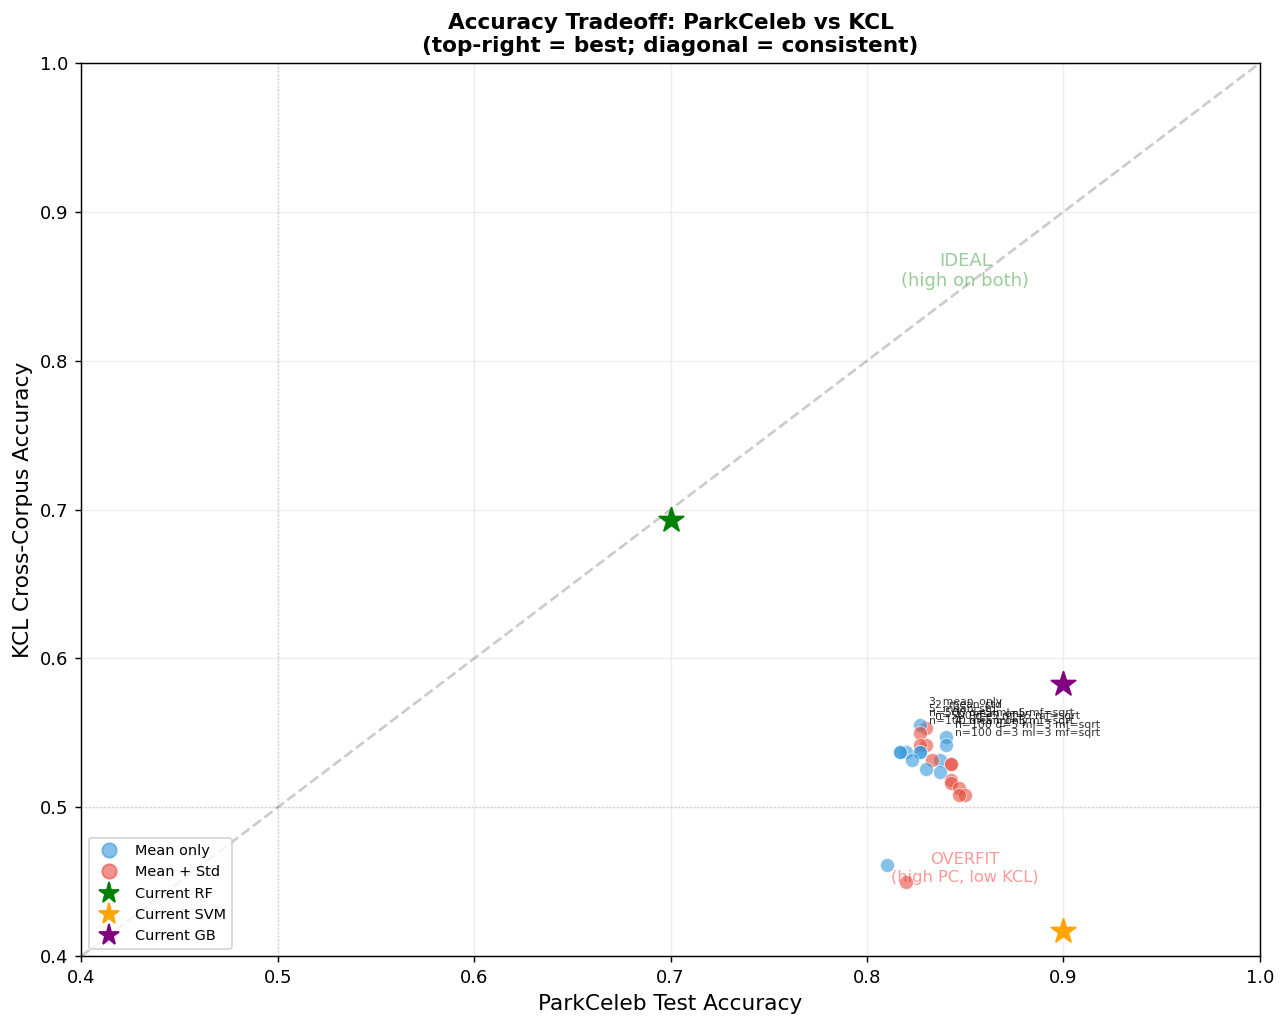

In [9]:
# ============================================================
# Scatter plot: ParkCeleb accuracy vs KCL accuracy
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'mean_only': '#3498DB', 'mean_std': '#E74C3C'}

for (agg, cfg), r in summary.iterrows():
    ax.scatter(r['pc_acc'], r['kcl_acc'], c=colors[agg], s=60, alpha=0.6,
              edgecolors='white', linewidth=0.5)

# Label top 5
for i, ((agg, cfg), r) in enumerate(summary.head(5).iterrows()):
    ax.annotate(f'{i+1}. {agg}\n{cfg}',
               (r['pc_acc'], r['kcl_acc']),
               fontsize=6, alpha=0.8, xytext=(5, 5), textcoords='offset points')

# Reference lines
ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.3)
ax.axvline(0.5, color='gray', ls=':', lw=0.8, alpha=0.3)
ax.plot([0.4, 1], [0.4, 1], 'k--', alpha=0.2, label='Equal performance')

# Mark where your current models sit
ax.scatter(0.70, 0.693, marker='*', s=200, c='green', zorder=5, label='Current RF')
ax.scatter(0.90, 0.417, marker='*', s=200, c='orange', zorder=5, label='Current SVM')
ax.scatter(0.90, 0.583, marker='*', s=200, c='purple', zorder=5, label='Current GB')

mean_patch = plt.Line2D([0], [0], marker='o', color='#3498DB', lw=0, ms=8, alpha=0.6, label='Mean only')
std_patch = plt.Line2D([0], [0], marker='o', color='#E74C3C', lw=0, ms=8, alpha=0.6, label='Mean + Std')
ax.legend(handles=[mean_patch, std_patch,
                   plt.Line2D([0],[0], marker='*', color='green', lw=0, ms=12, label='Current RF'),
                   plt.Line2D([0],[0], marker='*', color='orange', lw=0, ms=12, label='Current SVM'),
                   plt.Line2D([0],[0], marker='*', color='purple', lw=0, ms=12, label='Current GB')],
          loc='lower left', fontsize=8)

ax.set_xlabel('ParkCeleb Test Accuracy', fontsize=12)
ax.set_ylabel('KCL Cross-Corpus Accuracy', fontsize=12)
ax.set_title('Accuracy Tradeoff: ParkCeleb vs KCL\n(top-right = best; diagonal = consistent)')
ax.set_xlim(0.4, 1.0); ax.set_ylim(0.4, 1.0)
ax.grid(alpha=0.2)

# Annotate ideal region
ax.annotate('IDEAL\n(high on both)', xy=(0.85, 0.85), fontsize=10,
           color='green', alpha=0.4, ha='center')
ax.annotate('OVERFIT\n(high PC, low KCL)', xy=(0.85, 0.45), fontsize=9,
           color='red', alpha=0.4, ha='center')

plt.tight_layout()
plt.savefig('rf_pc_vs_kcl_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

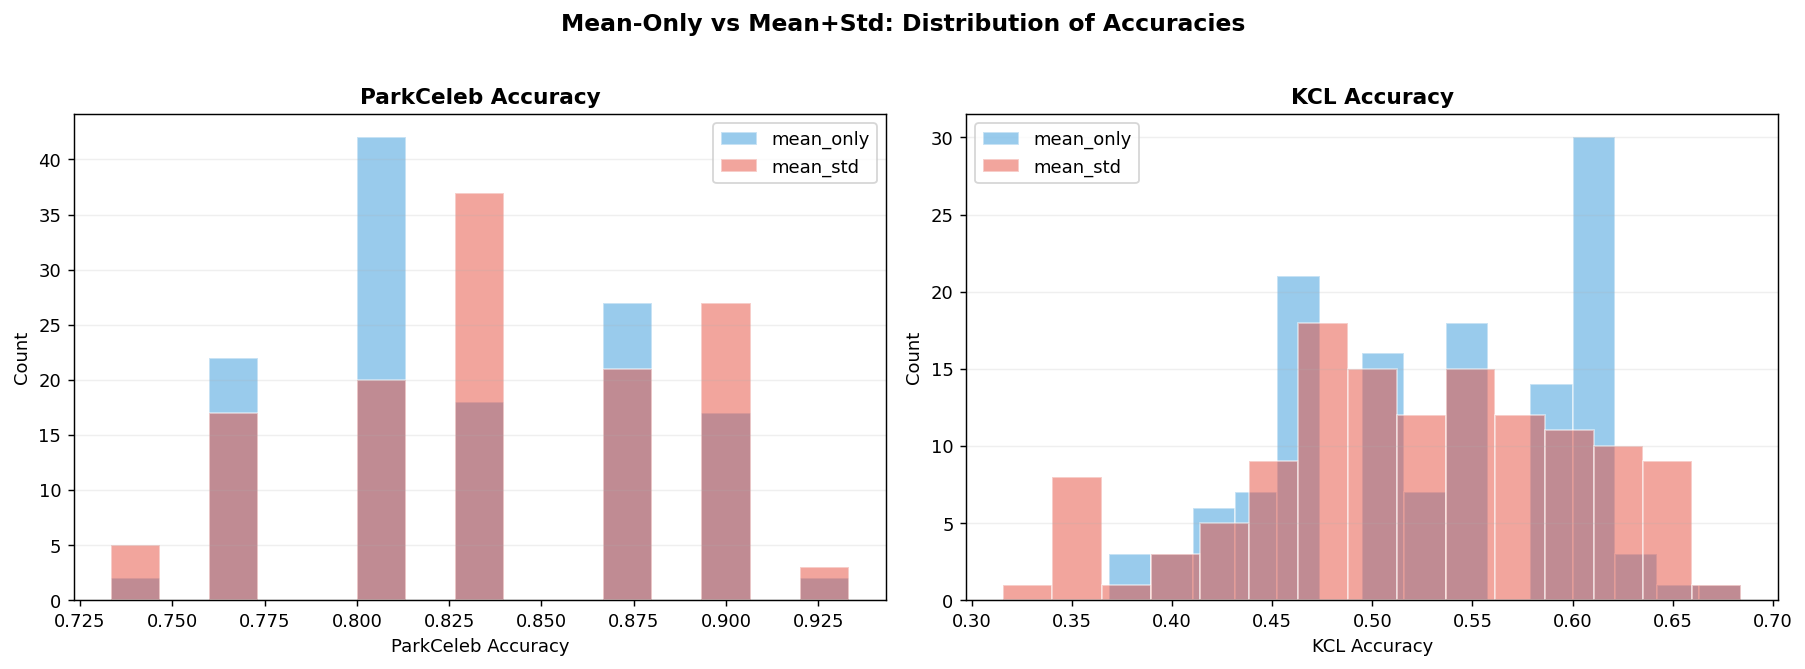

 mean_only: PC acc=0.827±0.047  KCL acc=0.531±0.069  Combined=0.643
  mean_std: PC acc=0.837±0.050  KCL acc=0.522±0.087  Combined=0.639


In [10]:
# ============================================================
# Mean-only vs Mean+Std comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [(axes[0], 'pc_acc', 'ParkCeleb Accuracy'),
                           (axes[1], 'kcl_acc', 'KCL Accuracy')]:
    for agg, color in [('mean_only', '#3498DB'), ('mean_std', '#E74C3C')]:
        vals = res_df[res_df['agg'] == agg][metric]
        ax.hist(vals, bins=15, alpha=0.5, color=color, label=agg, edgecolor='white')
    ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.set_title(label); ax.legend(); ax.grid(axis='y', alpha=0.2)

plt.suptitle('Mean-Only vs Mean+Std: Distribution of Accuracies',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('rf_agg_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Print stats
for agg in ['mean_only', 'mean_std']:
    sub = res_df[res_df['agg'] == agg]
    print(f'{agg:>10s}: PC acc={sub["pc_acc"].mean():.3f}±{sub["pc_acc"].std():.3f}  '
          f'KCL acc={sub["kcl_acc"].mean():.3f}±{sub["kcl_acc"].std():.3f}  '
          f'Combined={sub["combined"].mean():.3f}')

In [12]:
# ============================================================
# Train the BEST GENERALISING model and save
# ============================================================
best_agg, best_cfg = summary.index[0]
best_row = summary.iloc[0]

print(f'Best generalising config:')
print(f'  Aggregation : {best_agg}')
print(f'  RF config   : {best_cfg}')
print(f'  PC accuracy : {best_row["pc_acc"]:.3f} ± {best_row["pc_acc_std"]:.3f}')
print(f'  KCL accuracy: {best_row["kcl_acc"]:.3f} ± {best_row["kcl_acc_std"]:.3f}')
print(f'  Combined    : {best_row["combined"]:.3f}')

# Parse config string back to params
import re
parts = dict(re.findall(r'(\w+)=(\S+)', best_cfg))
best_params = {
    'n_estimators': int(parts['n']),
    'max_depth': None if parts['d'] == 'None' else int(parts['d']),
    'min_samples_leaf': int(parts['ml']),
    'max_features': None if parts['mf'] == 'None' else parts['mf'],
}

# Train on ALL ParkCeleb subjects (for maximum cross-corpus performance)
pc_subj_final, feat_cols_final = aggregate_subjects(pc_df, base_features, mode=best_agg)

final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(pc_subj_final[feat_cols_final].values)
y_all = pc_subj_final['label'].values

final_rf = RandomForestClassifier(**best_params, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
final_rf.fit(X_all, y_all)

# Save
joblib.dump({
    'model': final_rf,
    'scaler': final_scaler,
    'features': feat_cols_final,
    'base_features': base_features,
    'aggregation': best_agg,
    'params': best_params,
    'pc_acc': best_row['pc_acc'],
    'kcl_acc': best_row['kcl_acc'],
    'combined': best_row['combined'],
}, 'rf_best_generalising.joblib')
print(f'\nSaved: rf_best_generalising.joblib')

Best generalising config:
  Aggregation : mean_only
  RF config   : n=100 d=5 ml=3 mf=sqrt
  PC accuracy : 0.840 ± 0.047
  KCL accuracy: 0.547 ± 0.048
  Combined    : 0.661

Saved: rf_best_generalising.joblib


FINAL KCL CROSS-CORPUS EVALUATION (trained on ALL ParkCeleb)
  Accuracy : 0.579
  AUC      : 0.588
  F1       : 0.619

  Subject     True  Pred  OK   P(PD)
  ───────────────────────────────────
  ID00          CN    PD   ✗   0.591
  ID01          CN    CN   ✓   0.422
  ID02          PD    PD   ✓   0.615
  ID03          CN    CN   ✓   0.427
  ID04          PD    PD   ✓   0.723
  ID05          CN    CN   ✓   0.497
  ID06          PD    PD   ✓   0.684
  ID07          PD    PD   ✓   0.780
  ID08          CN    PD   ✗   0.534
  ID09          CN    PD   ✗   0.567
  ID10          CN    PD   ✗   0.512
  ID11          CN    CN   ✓   0.494
  ID12          CN    PD   ✗   0.767
  ID13          PD    PD   ✓   0.519
  ID14          CN    PD   ✗   0.629
  ID15          CN    PD   ✗   0.713
  ID16          PD    PD   ✓   0.628
  ID17          PD    CN   ✗   0.436
  ID18          PD    CN   ✗   0.321
  ID19          CN    PD   ✗   0.654
  ID20          PD    PD   ✓   0.623
  ID21          CN    CN   ✓ 

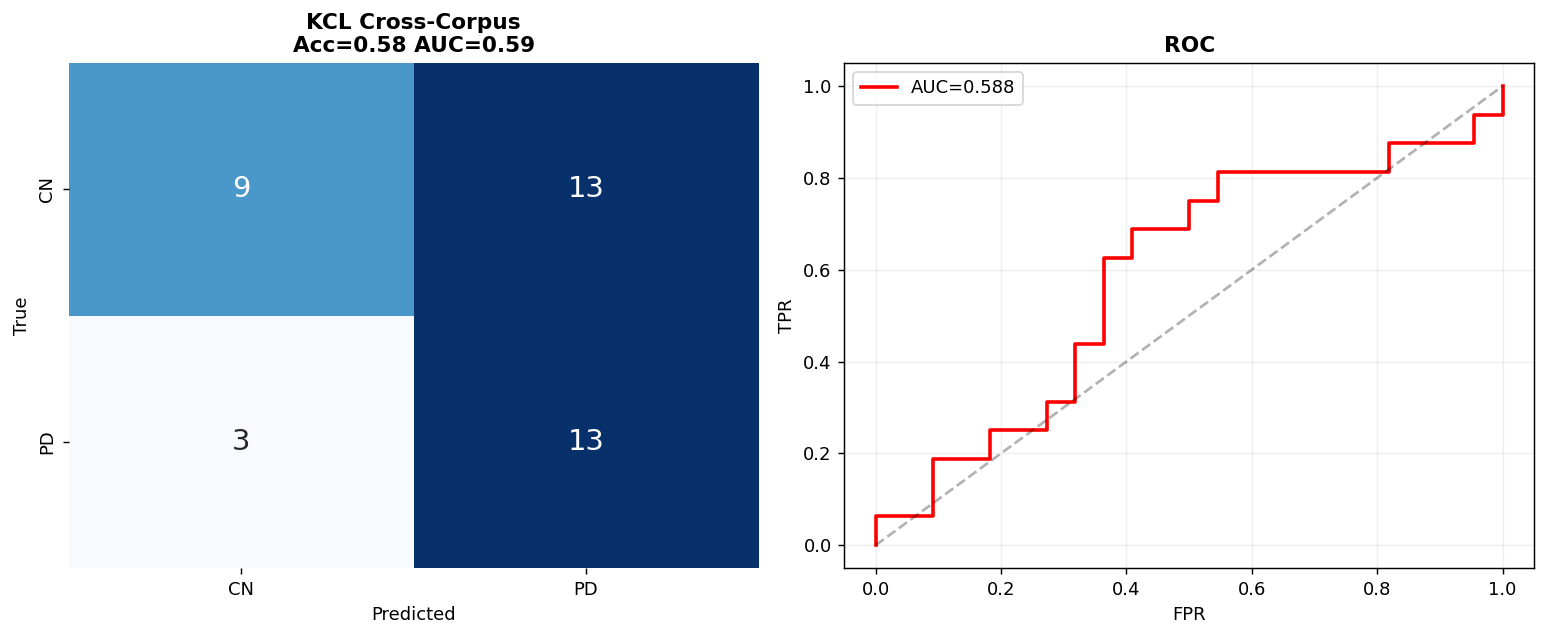

In [13]:
# ============================================================
# Final KCL evaluation with the best model
# ============================================================
if kcl_all is not None:
    if best_agg == 'mean_only':
        kcl_subj = kcl_all.groupby('subject').agg(
            {**{f: 'mean' for f in base_features}, 'label': 'first'}
        ).reset_index()
    else:
        kcl_subj, _ = aggregate_subjects(kcl_all, base_features, mode=best_agg)
    
    for col in feat_cols_final:
        if col not in kcl_subj.columns:
            kcl_subj[col] = 0.0
    
    X_kcl = final_scaler.transform(kcl_subj[feat_cols_final].fillna(0).values)
    y_kcl = kcl_subj['label'].values
    kcl_pred = final_rf.predict(X_kcl)
    kcl_prob = final_rf.predict_proba(X_kcl)[:, 1]
    
    kcl_acc = accuracy_score(y_kcl, kcl_pred)
    kcl_auc = roc_auc_score(y_kcl, kcl_prob)
    kcl_f1 = f1_score(y_kcl, kcl_pred, zero_division=0)
    
    print(f'FINAL KCL CROSS-CORPUS EVALUATION (trained on ALL ParkCeleb)')
    print(f'  Accuracy : {kcl_acc:.3f}')
    print(f'  AUC      : {kcl_auc:.3f}')
    print(f'  F1       : {kcl_f1:.3f}')
    
    # Per-subject
    print(f'\n  {"Subject":<10s} {"True":>5s} {"Pred":>5s} {"OK":>3s} {"P(PD)":>7s}')
    print(f'  {"─"*35}')
    for i, row in kcl_subj.iterrows():
        true = 'PD' if y_kcl[i] == 1 else 'CN'
        pred = 'PD' if kcl_pred[i] == 1 else 'CN'
        ok = '✓' if true == pred else '✗'
        print(f'  {row["subject"]:<10s} {true:>5s} {pred:>5s} {ok:>3s} {kcl_prob[i]:>7.3f}')
    
    wrong = sum(y_kcl != kcl_pred)
    print(f'\n  Misclassified: {wrong}/{len(y_kcl)}')
    
    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm = confusion_matrix(y_kcl, kcl_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['CN','PD'], yticklabels=['CN','PD'], cbar=False, annot_kws={'size':16})
    axes[0].set_title(f'KCL Cross-Corpus\nAcc={kcl_acc:.2f} AUC={kcl_auc:.2f}')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    
    fpr, tpr, _ = roc_curve(y_kcl, kcl_prob)
    axes[1].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={kcl_auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC'); axes[1].legend(); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.savefig('rf_best_kcl_eval.png', dpi=150, bbox_inches='tight'); plt.show()